# 07 — Model Experiments

This notebook performs SHAP interpretability, generates clinical flags, retrains the models with these features, and computes bootstrap confidence intervals for the tuned and calibrated model and plots.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from pathlib import Path
from src.features import load_preprocessed_with_names, create_clinical_flags
from src.modeling import train_models_with_flags, compute_metrics, get_y_prob
from src.evaluation import (
    evaluate_models_with_flags, compare_baseline_vs_flags, 
    compute_deltas_for_all_models, evaluate_calibrated_model_with_bootstrap, compute_shap
)
from src.config import SEED
from src.visualization import (
    plot_roc_curve, plot_pr_curve, plot_calibration_curves,
    plot_probability_distribution, plot_shap_beeswarm
)

In [2]:
# Load tuned model and calibrator
model = joblib.load("../models/logistic_regression_tuned.pkl")
calibrator = joblib.load("../models/logistic_regression_tuned_calibrator.pkl")

# Load preprocessor
preprocessor = joblib.load("../models/preprocessor.pkl")

# Load full dataset and data
df = pd.read_csv("../data/processed/final_migraine.csv")
X_tr_prep = pd.read_csv("../data/processed/X_tr_prep.csv")
X_te_prep = pd.read_csv("../data/processed/X_te_prep.csv")
y_tr = pd.read_csv("../data/processed/y_tr.csv").squeeze()
y_te = pd.read_csv("../data/processed/y_te.csv").squeeze()
test_metrics = pd.read_csv("../reports/tables/test_metrics.csv", index_col=0)

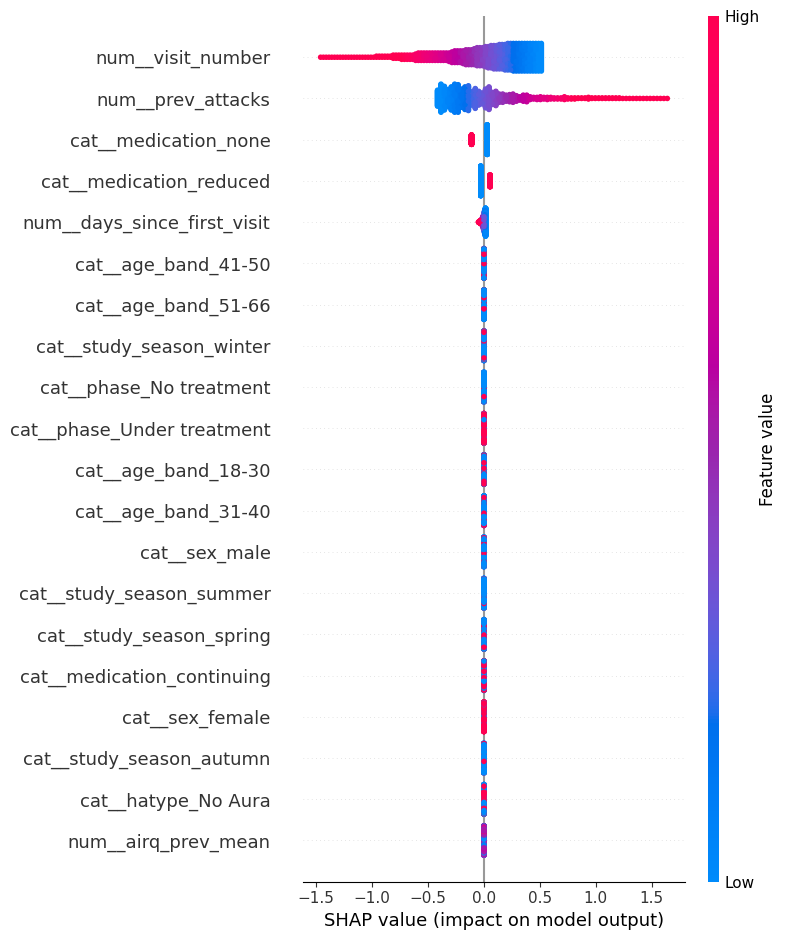

In [3]:
# SHAP analysis
feature_names = preprocessor.get_feature_names_out()
X_shap = pd.DataFrame(X_te_prep, columns=feature_names)

shap_values, X_shap = compute_shap(model, X_shap, n_samples=None)
shap.summary_plot(shap_values, X_shap)

In [4]:
# Create clinical flags and retrain models
X_tr_prep_f = load_preprocessed_with_names(
    "../data/processed/X_tr_prep.csv",
    "../models/preprocessor.pkl"
)

X_te_prep_f = load_preprocessed_with_names(
    "../data/processed/X_te_prep.csv",
    "../models/preprocessor.pkl"
)

X_tr_flags, X_te_flags = create_clinical_flags(X_tr_prep_f, X_te_prep_f)

In [5]:
# Train models with flags
rl_model_flags, gb_model_flags, xgb_model_flags = train_models_with_flags(
    X_tr_flags, y_tr, SEED
)

In [6]:
# Evaluate models with flags
metrics_flags_df = evaluate_models_with_flags(
    rl_model_flags, gb_model_flags, xgb_model_flags,
    X_te_flags, y_te, compute_metrics
)

metrics_flags_df.to_csv("../reports/tables/metrics_flags.csv", index=True)
metrics_flags_df

,ROC-AUC,PR-AUC,Brier,ECE,TP,TN,FP,FN,Precision,Sensitivity
logistic_regression_flags,0.707693,0.746885,0.215081,0.077223,433.0,157.0,198.0,91.0,0.686212,0.826336
gradient_boosting_flags,0.665316,0.719159,0.233178,0.096593,411.0,155.0,200.0,113.0,0.672668,0.784351
xgboost_flags,0.647248,0.700540,0.244918,0.127016,411.0,146.0,209.0,113.0,0.662903,0.784351


In [7]:
# Compare baseline vs flags
comparison_df = compare_baseline_vs_flags(test_metrics, metrics_flags_df)
comparison_df.to_csv("../reports/tables/test_metrics_comparison_base_vs_flags.csv")
comparison_df

,ROC-AUC,PR-AUC,Brier,ECE,TP,TN,FP,FN,Precision,Sensitivity
logistic_regression,0.707714,0.748533,0.215358,0.073488,433.0,158.0,197.0,91.0,0.687302,0.826336
gradient_boosting,0.664751,0.718180,0.233590,0.099338,409.0,155.0,200.0,115.0,0.671593,0.780534
xgboost,0.654075,0.705607,0.242724,0.130866,412.0,147.0,208.0,112.0,0.664516,0.786260
logistic_regression_flags,0.707693,0.746885,0.215081,0.077223,433.0,157.0,198.0,91.0,0.686212,0.826336
gradient_boosting_flags,0.665316,0.719159,0.233178,0.096593,411.0,155.0,200.0,113.0,0.672668,0.784351
xgboost_flags,0.647248,0.700540,0.244918,0.127016,411.0,146.0,209.0,113.0,0.662903,0.784351


In [8]:
# Compute deltas
deltas_df = compute_deltas_for_all_models(comparison_df)
deltas_df.to_csv("../reports/tables/test_metrics_deltas_base_vs_flags.csv", index=False)
deltas_df.head(10)

,Metric,Baseline,With Flags,Absolute Δ,Relative Δ (%),Model
0,ROC-AUC,0.707714,0.707693,-0.000022,-0.003038,logistic_regression
1,PR-AUC,0.748533,0.746885,-0.001647,-0.220056,logistic_regression
2,Brier,0.215358,0.215081,-0.000278,-0.128967,logistic_regression
3,ECE,0.073488,0.077223,0.003736,5.083289,logistic_regression
4,TP,433.000000,433.000000,0.000000,0.000000,logistic_regression
5,TN,158.000000,157.000000,-1.000000,-0.632911,logistic_regression
6,FP,197.000000,198.000000,1.000000,0.507614,logistic_regression
7,FN,91.000000,91.000000,0.000000,0.000000,logistic_regression
8,Precision,0.687302,0.686212,-0.001089,-0.158479,logistic_regression
9,Sensitivity,0.826336,0.826336,0.000000,0.000000,logistic_regression


In [9]:
# Bootstrap
bootstrap_df = evaluate_calibrated_model_with_bootstrap(
    base_model=model,
    calibrator=calibrator,
    X_test=X_te_prep,
    y_test=y_te,
    n_boot=1000,
    seed=SEED
)

bootstrap_df.to_csv("../reports/tables/bootstrap.csv", index=True)
bootstrap_df.T

,roc,pr,brier,ece,tp,tn,fp,fn,precision,sensitivity
Mean,0.715217,0.753775,0.214474,0.074227,453.503000,135.096000,220.773000,69.628000,0.672571,0.866893
Std,0.017893,0.020181,0.007324,0.012616,15.154471,10.903063,12.960535,8.017207,0.018311,0.014967
CI95_low,0.680907,0.711342,0.200350,0.050767,424.000000,113.975000,196.000000,55.000000,0.637981,0.836386
CI95_high,0.749386,0.792115,0.229531,0.099561,483.000000,156.000000,246.000000,86.000000,0.708347,0.894162
Point,0.715614,0.754358,0.214154,0.065473,454.000000,135.000000,220.000000,70.000000,0.673591,0.866412


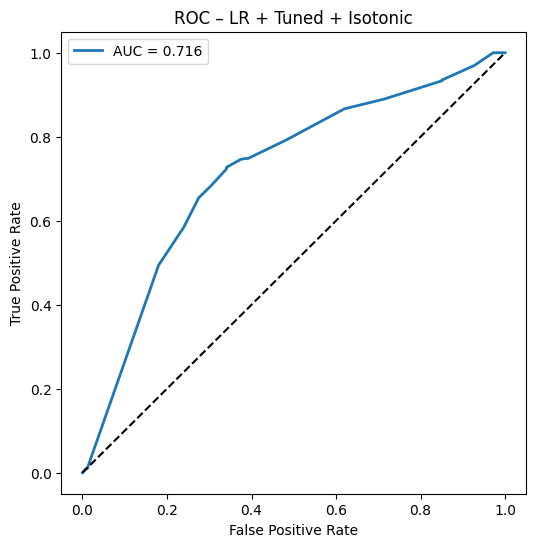

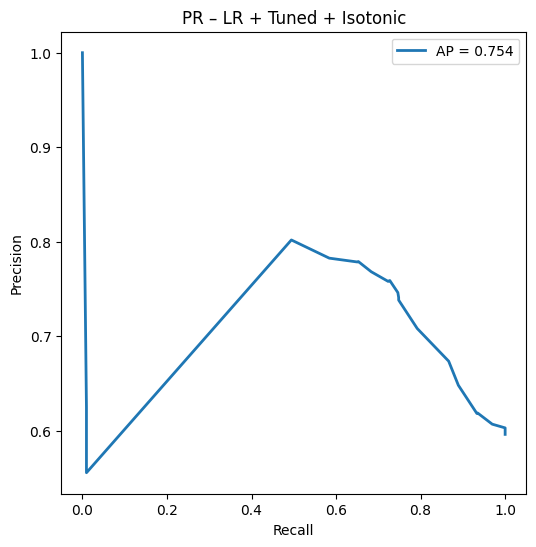

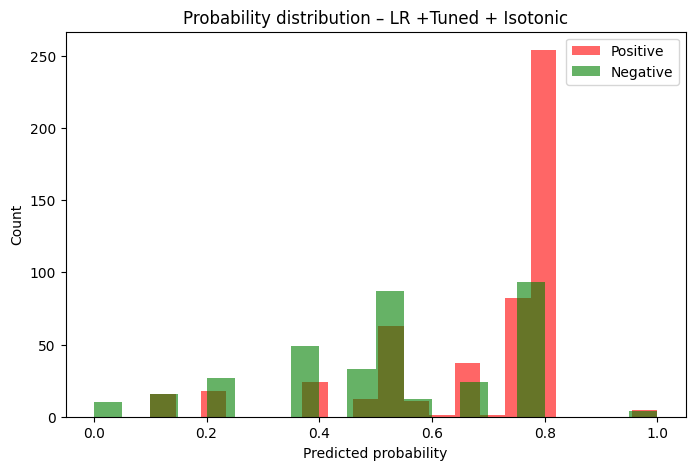

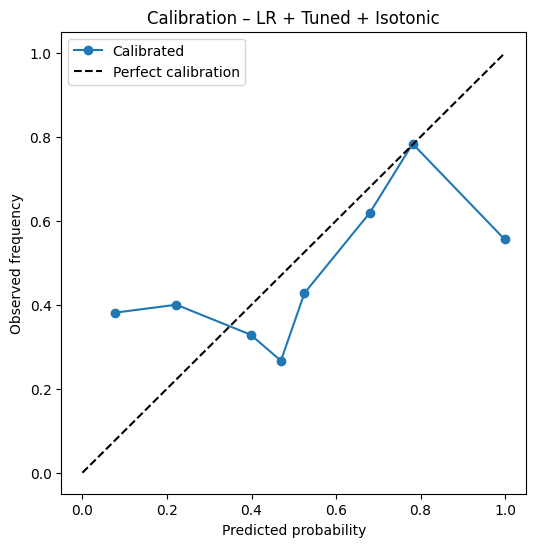

In [11]:
# Visualization LR + tuned + isotonic
y_prob = get_y_prob(model, calibrator, X_te_prep)
pd.Series(y_prob).to_pickle("../reports/tables/y_prob.pkl")
pd.DataFrame({"y_prob": y_prob}).to_csv("../reports/tables/y_prob_full.csv", index=False)  # ← afegeix
joblib.dump({"model": model, "calibrator": calibrator, "preprocessor": preprocessor}, "../models/final_pipeline.pkl")

fig_roc = plot_roc_curve(model, X_te_prep, y_te, "ROC – LR + Tuned + Isotonic", y_prob=y_prob)
fig_roc.savefig("../reports/figures/final_roc.png", dpi=300, bbox_inches="tight")

fig_pr = plot_pr_curve(model, X_te_prep, y_te, "PR – LR + Tuned + Isotonic", y_prob=y_prob)
fig_pr.savefig("../reports/figures/final_pr.png", dpi=300, bbox_inches="tight")

fig_dist = plot_probability_distribution(y_te, y_prob, "Probability distribution – LR +Tuned + Isotonic")
fig_dist.savefig("../reports/figures/final_distribution.png", dpi=300, bbox_inches="tight")

fig_cal = plot_calibration_curves(None, None, None, y_te, y_prob=y_prob, title="Calibration – LR + Tuned + Isotonic")
fig_cal.savefig("../reports/figures/final_calibration.png", dpi=300, bbox_inches="tight")